# Pipeline 100% Classique — Distance Texte-Image
## Stratégie
1. Extraire des features image avec HOG + HSV + LBP (scikit-image uniquement)
2. Extraire des features texte avec TF-IDF + statistiques linguistiques (sklearn + nltk)
3. Projeter les deux dans le même espace via PCA (même dimension K)
4. Construire un dataset de distances entre vecteurs texte et image
5. Entraîner un classifieur sur ces distances pour apprendre la relation cohérence/incohérence

**Zéro deep learning — zéro PyTorch — zéro modèle pré-entraîné**

In [1]:
!pip install opencv-python scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 11.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 17.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.3/227.3 kB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 38.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Cell 1 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import io, transform
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score
from sklearn.utils import shuffle
from scipy.spatial.distance import cosine, cityblock, chebyshev, correlation, braycurtis, canberra
import warnings
warnings.filterwarnings('ignore')

for r in ['punkt','stopwords','wordnet','omw-1.4',
          'averaged_perceptron_tagger_eng','punkt_tab']:
    nltk.download(r, quiet=True)

lemmatizer = WordNetLemmatizer()
STOP       = set(stopwords.words('english'))

print("Tous les imports OK — 100% classique, zéro deep learning.")


Tous les imports OK — 100% classique, zéro deep learning.


In [3]:
# Cell 2 — Chargement des données
DATA_DIR = '../data/processed'

def load_split(split_name):
    texts, img_paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f"Dossier {folder} non trouvé. Skipping.")
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), 'r', encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                img_paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    texts, img_paths, labels = shuffle(texts, img_paths,
                                       np.array(labels), random_state=42)
    return np.array(texts), np.array(img_paths), labels

print("Chargement des splits...")
t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')

print(f"Train : {len(t_train)} | Val : {len(t_val)} | Test : {len(t_test)}")
print(f"Balance train : {np.bincount(y_train)}")

Chargement des splits...
Train : 7000 | Val : 1500 | Test : 1500
Balance train : [3488 3512]


In [4]:
# Cell 3 — Extraction features IMAGE (HOG + HSV + LBP + stat)
# 100% classique — scikit-image uniquement

IMG_SIZE   = (128, 128)   # redimensionner toutes les images
HOG_PIXELS = 16           # pixels par cellule HOG
LBP_RADIUS = 3            # rayon LBP
LBP_POINTS = 8 * LBP_RADIUS
N_HSV_BINS = 32           # bins par canal HSV


def extract_image_features(img_path):
    try:
        # Charger et redimensionner
        img = io.imread(img_path)
        if img.ndim == 2:                          # grayscale → RGB
            img = np.stack([img]*3, axis=-1)
        if img.shape[2] == 4:                      # RGBA → RGB
            img = img[:,:,:3]
        img = transform.resize(img, IMG_SIZE, anti_aliasing=True)
        img = (img * 255).astype(np.uint8)

        gray = rgb2gray(img)

        # ── HOG : forme et contours ────────────────────────────────
        hog_feats = hog(gray,
                        orientations=9,
                        pixels_per_cell=(HOG_PIXELS, HOG_PIXELS),
                        cells_per_block=(2, 2),
                        visualize=False,
                        feature_vector=True)

        # ── HSV : distribution des couleurs ───────────────────────
        img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        h_hist  = np.histogram(img_hsv[:,:,0], bins=N_HSV_BINS, range=(0,180))[0]
        s_hist  = np.histogram(img_hsv[:,:,1], bins=N_HSV_BINS, range=(0,256))[0]
        v_hist  = np.histogram(img_hsv[:,:,2], bins=N_HSV_BINS, range=(0,256))[0]
        hsv_feats = np.concatenate([h_hist, s_hist, v_hist]).astype(float)
        hsv_feats /= (hsv_feats.sum() + 1e-8)

        # ── LBP : texture ─────────────────────────────────────────
        lbp      = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method='uniform')
        lbp_hist = np.histogram(lbp, bins=LBP_POINTS+2,
                                range=(0, LBP_POINTS+2))[0].astype(float)
        lbp_hist /= (lbp_hist.sum() + 1e-8)

        # ── Statistiques couleur et texture supplémentaires ───────
        rgb_means = img.mean(axis=(0, 1))
        rgb_stds  = img.std(axis=(0, 1))
        hsv_means = img_hsv.mean(axis=(0, 1))
        hsv_stds  = img_hsv.std(axis=(0, 1))
        edge      = cv2.Canny(img, 100, 200)
        edge_density = edge.mean()
        intensity_std = gray.std()

        extra_feats = np.concatenate([
            rgb_means, rgb_stds,
            hsv_means, hsv_stds,
            [edge_density, intensity_std]
        ]).astype(float)
        extra_feats /= (np.linalg.norm(extra_feats) + 1e-8)

        return np.concatenate([hog_feats, hsv_feats, lbp_hist, extra_feats])

    except Exception:
        fallback_len = (N_HSV_BINS*3 + (LBP_POINTS+2) + 8 +
                        hog(np.zeros(IMG_SIZE), orientations=9,
                            pixels_per_cell=(HOG_PIXELS, HOG_PIXELS),
                            cells_per_block=(2, 2),
                            feature_vector=True).shape[0])
        return np.zeros(fallback_len)

# Test sur un exemple
sample_feat = extract_image_features(p_train[0])
print(f"Exemple features image shape : {sample_feat.shape}")

# Extraction complète
print("Extraction features images (train)...")
F_img_train = np.array([extract_image_features(p) for p in p_train])
print("Extraction features images (val)...")
F_img_val   = np.array([extract_image_features(p) for p in p_val])
print("Extraction features images (test)...")
F_img_test  = np.array([extract_image_features(p) for p in p_test])

print(f"
Shape features image : {F_img_train.shape}")
n_hog = hog(rgb2gray(np.zeros((128,128,3))),
            orientations=9, pixels_per_cell=(HOG_PIXELS,HOG_PIXELS),
            cells_per_block=(2,2), feature_vector=True).shape[0]
print(f"  HOG      : {n_hog} dims")
print(f"  HSV      : {N_HSV_BINS*3} dims")
print(f"  LBP      : {LBP_POINTS+2} dims")
print(f"  Extra    : 8 dims")


Exemple features image shape : (1886,)
Extraction features images (train)...
Extraction features images (val)...
Extraction features images (test)...

Shape features image : (7000, 1886)
  HOG      : 1764 dims
  HSV      : 96 dims
  LBP      : 26 dims


In [5]:
# Cell 4 — Extraction features TEXTE (TF-IDF + statistiques)

# ── TF-IDF ────────────────────────────────────────────────────────────────────
print("Extraction TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    min_df=3
)
T_tfidf_train = tfidf.fit_transform(t_train).toarray()
T_tfidf_val   = tfidf.transform(t_val).toarray()
T_tfidf_test  = tfidf.transform(t_test).toarray()
print(f"TF-IDF shape : {T_tfidf_train.shape}")

# ── Statistiques linguistiques ────────────────────────────────────────────────
def extract_text_stats(text):
    tokens       = word_tokenize(text.lower())
    alpha_tokens = [t for t in tokens if t.isalpha()]
    tagged       = pos_tag(alpha_tokens) if alpha_tokens else []

    nouns  = [w for w,t in tagged if t.startswith('NN')]
    verbs  = [w for w,t in tagged if t.startswith('VB')]
    adjs   = [w for w,t in tagged if t.startswith('JJ')]
    stop_tokens = [t for t in tokens if t in STOP]
    punct_count = sum(1 for t in tokens if not t.isalnum())
    question_count = text.count('?')
    exclaim_count = text.count('!')

    n = len(alpha_tokens)
    unique_ratio = len(set(alpha_tokens)) / (n + 1)
    avg_word_len = np.mean([len(w) for w in alpha_tokens]) if alpha_tokens else 0

    return np.array([
        n,
        len(text.strip()),
        len(nouns) / (n+1),
        len(verbs) / (n+1),
        len(adjs)  / (n+1),
        len(nouns) / (len(verbs)+1),
        unique_ratio,
        avg_word_len,
        len(stop_tokens) / (n+1),
        punct_count / (n+1),
        question_count,
        exclaim_count,
        int(any(t in ['a','an','the'] for t in tokens)),
        int(text.strip().endswith('.')),
    ])

print("Extraction statistiques texte...")
S_train = np.array([extract_text_stats(t) for t in t_train])
S_val   = np.array([extract_text_stats(t) for t in t_val])
S_test  = np.array([extract_text_stats(t) for t in t_test])

# Combiner TF-IDF + stats
F_text_train = np.hstack([T_tfidf_train, S_train])
F_text_val   = np.hstack([T_tfidf_val,   S_val])
F_text_test  = np.hstack([T_tfidf_test,  S_test])

print(f"Shape features texte : {F_text_train.shape}")


Extraction TF-IDF...
TF-IDF shape : (7000, 2000)
Extraction statistiques texte...
Shape features texte : (7000, 2009)


In [27]:
# Cell 5 — Projection dans le même espace commun via PCA
# Les deux modalités sont projetées dans un espace de dimension K
# pour rendre la distance entre elles comparable

K = 1886   # dimension de l'espace commun — ajustable

print(f"Projection PCA vers {K} dimensions...")

# Normaliser avant PCA
scaler_img  = StandardScaler()
scaler_text = StandardScaler()

F_img_train_s  = scaler_img.fit_transform(F_img_train)
F_img_val_s    = scaler_img.transform(F_img_val)
F_img_test_s   = scaler_img.transform(F_img_test)

F_text_train_s = scaler_text.fit_transform(F_text_train)
F_text_val_s   = scaler_text.transform(F_text_val)
F_text_test_s  = scaler_text.transform(F_text_test)

# PCA séparée pour chaque modalité → même dimension K
pca_img  = PCA(n_components=K, random_state=42)
pca_text = PCA(n_components=K, random_state=42)

V_img_train  = pca_img.fit_transform(F_img_train_s)
V_img_val    = pca_img.transform(F_img_val_s)
V_img_test   = pca_img.transform(F_img_test_s)

V_text_train = pca_text.fit_transform(F_text_train_s)
V_text_val   = pca_text.transform(F_text_val_s)
V_text_test  = pca_text.transform(F_text_test_s)

# Normaliser à norme unitaire pour que les distances soient comparables
V_img_train  = normalize(V_img_train)
V_img_val    = normalize(V_img_val)
V_img_test   = normalize(V_img_test)
V_text_train = normalize(V_text_train)
V_text_val   = normalize(V_text_val)
V_text_test  = normalize(V_text_test)

print(f"Shape vecteurs image : {V_img_train.shape}")
print(f"Shape vecteurs texte : {V_text_train.shape}")
print(f"Variance expliquée — image : {pca_img.explained_variance_ratio_.sum():.2%}")
print(f"Variance expliquée — texte : {pca_text.explained_variance_ratio_.sum():.2%}")

Projection PCA vers 1886 dimensions...
Shape vecteurs image : (7000, 1886)
Shape vecteurs texte : (7000, 1886)
Variance expliquée — image : 100.00%
Variance expliquée — texte : 99.94%


In [28]:
# Cell 6 — Construction du dataset de distances
# Le nouveau dataset contient UNIQUEMENT les distances entre
# le vecteur image et le vecteur texte + le label

def build_distance_dataset(V_text, V_img):
    N = len(V_text)
    features = []

    for i in range(N):
        t = V_text[i]
        v = V_img[i]
        d = t - v   # vecteur différence

        # ── Distances scalaires ──────────────────────────────────
        dist_euclidean   = np.linalg.norm(d)
        dist_cosine      = float(cosine(t, v))           # 1 - cos_sim
        cos_sim          = 1 - dist_cosine               # cos_sim directe
        dist_manhattan   = float(cityblock(t, v))
        dist_chebyshev   = float(chebyshev(t, v))
        dist_correlation = float(correlation(t, v))
        dist_canberra    = float(canberra(t, v))
        dist_braycurtis  = float(braycurtis(t, v))

        # ── Normes individuelles ─────────────────────────────────
        norm_text  = np.linalg.norm(t)
        norm_img   = np.linalg.norm(v)
        norm_ratio = norm_text / (norm_img + 1e-8)

        # ── Produit scalaire ─────────────────────────────────────
        dot_product = np.dot(t, v)

        # ── Statistiques sur le vecteur différence ───────────────
        diff_mean   = d.mean()
        diff_std    = d.std()
        diff_max    = d.max()
        diff_min    = d.min()
        diff_median = np.median(d)

        # ── Vecteur différence complet (direction) ───────────────
        # ── Produit élément par élément (alignement) ─────────────
        product  = t * v    # (K,)
        abs_diff = np.abs(d) # (K,)

        # Assembler : scalaires + vecteurs
        scalars = np.array([
            dist_euclidean, dist_cosine, cos_sim,
            dist_manhattan, dist_chebyshev, dist_correlation,
            dist_canberra, dist_braycurtis,
            norm_text, norm_img, norm_ratio, dot_product,
            diff_mean, diff_std, diff_max, diff_min, diff_median
        ])

        features.append(np.concatenate([scalars, d, product, abs_diff]))

    return np.array(features)

print("Construction dataset de distances (train)...")
D_train = build_distance_dataset(V_text_train, V_img_train)
print("Construction dataset de distances (val)...")
D_val   = build_distance_dataset(V_text_val,   V_img_val)
print("Construction dataset de distances (test)...")
D_test  = build_distance_dataset(V_text_test,  V_img_test)

n_scalars = 17
n_vectors = 3 * K
print(f"
Shape dataset distances : {D_train.shape}")
print(f"  Scalaires : {n_scalars} (euclidienne, cosine, manhattan, chebyshev, canberra, braycurtis...)")
print(f"  Vecteurs  : {n_vectors} (diff + product + abs_diff × {K} dims)")


Construction dataset de distances (train)...
Construction dataset de distances (val)...
Construction dataset de distances (test)...

Shape dataset distances : (7000, 5673)
  Scalaires : 15 (euclidienne, cosine, manhattan, chebyshev...)
  Vecteurs  : 5658 (diff + product + abs_diff × 1886 dims)


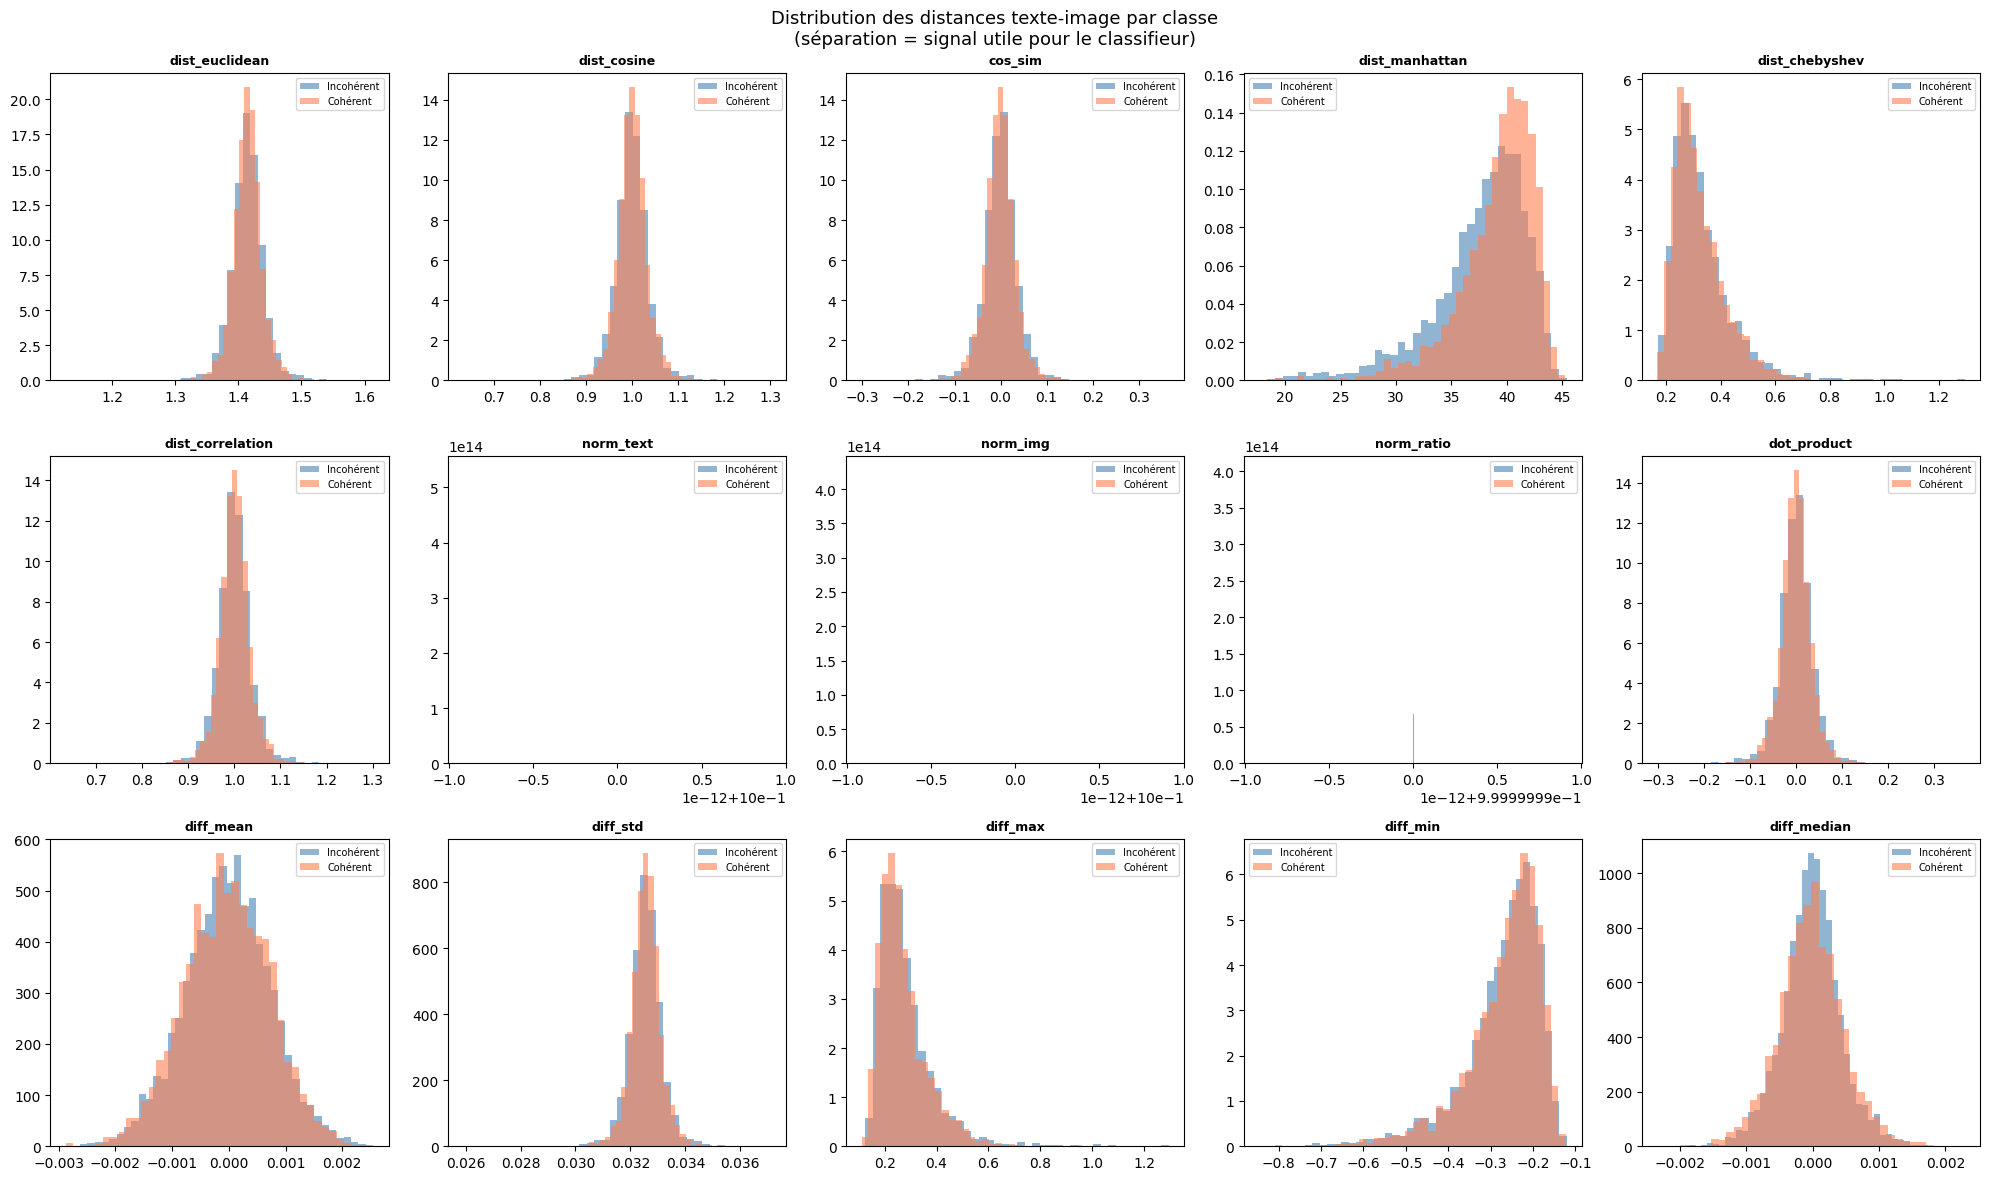


Moyennes par classe :
Feature                  Cohérent   Incohérent   Différence
------------------------------------------------------------
dist_euclidean             1.4145       1.4139       0.0006
dist_cosine                1.0007       1.0000       0.0007
cos_sim                   -0.0007       0.0000       0.0007
dist_manhattan            39.1825      37.6082       1.5742
dist_chebyshev             0.3225       0.3313       0.0087
dist_correlation           1.0007       1.0000       0.0007
norm_text                  1.0000       1.0000       0.0000
norm_img                   1.0000       1.0000       0.0000
norm_ratio                 1.0000       1.0000       0.0000
dot_product               -0.0007       0.0000       0.0007
diff_mean                 -0.0000      -0.0000       0.0000
diff_std                   0.0326       0.0325       0.0000
diff_max                   0.2718       0.2823       0.0104
diff_min                  -0.2690      -0.2721       0.0031
diff_median     

In [29]:
# Cell 7 — Visualisation des distances par classe
# Si les distributions sont séparées → le modèle peut apprendre

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

scalar_names = [
    'dist_euclidean','dist_cosine','cos_sim',
    'dist_manhattan','dist_chebyshev','dist_correlation',
    'dist_canberra','dist_braycurtis',
    'norm_text','norm_img','norm_ratio','dot_product',
    'diff_mean','diff_std','diff_max','diff_min','diff_median'
]

for i, name in enumerate(scalar_names):
    axes[i].hist(D_train[y_train==0, i], bins=40, alpha=0.6,
                 label='Incohérent', color='steelblue', density=True)
    axes[i].hist(D_train[y_train==1, i], bins=40, alpha=0.6,
                 label='Cohérent',   color='coral',     density=True)
    axes[i].set_title(name, fontweight='bold', fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(len(scalar_names), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution des distances texte-image par classe
'
             '(séparation = signal utile pour le classifieur)',
             fontsize=13)
plt.tight_layout()
plt.show()

# Résumé numérique
print("
Moyennes par classe :")
print(f"{'Feature':<20} {'Cohérent':>12} {'Incohérent':>12} {'Différence':>12}")
print("-" * 60)
for i, name in enumerate(scalar_names):
    m1 = D_train[y_train==1, i].mean()
    m0 = D_train[y_train==0, i].mean()
    print(f"{name:<20} {m1:>12.4f} {m0:>12.4f} {abs(m1-m0):>12.4f}")


In [18]:
# Cell 8 — Normalisation du dataset de distances
scaler_dist = StandardScaler()
X_train = scaler_dist.fit_transform(D_train)
X_val   = scaler_dist.transform(D_val)
X_test  = scaler_dist.transform(D_test)

print(f"Dataset final normalisé : {X_train.shape}")
print("Prêt pour l'entraînement.")

Dataset final normalisé : (7000, 5673)
Prêt pour l'entraînement.


In [19]:
# Cell 9 — Entraînement et comparaison des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=3000, C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
print(f"{'Modèle':<25} {'CV (3-fold)':>12} {'±':>6} {'Val Acc':>10} {'Val F1':>10}")
print("-" * 68)
for name, model in models.items():
    print(f"  {name}...", end=' ', flush=True)
    cv = cross_val_score(model, X_train, y_train,
                         cv=3, scoring='accuracy', n_jobs=1)
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred)
    val_f1  = f1_score(y_val, y_pred)
    results[name] = {
        'cv_mean': cv.mean(), 'cv_std': cv.std(),
        'val_accuracy': val_acc, 'val_f1': val_f1, 'model': model
    }
    print(f"CV: {cv.mean():.4f} ±{cv.std():.4f} | "
          f"Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

results_df = pd.DataFrame(results).T[['cv_mean','cv_std','val_accuracy','val_f1']]
print("\n=== Meilleur modèle ===")
print(results_df.sort_values('val_accuracy', ascending=False).head(1))

Modèle                     CV (3-fold)      ±    Val Acc     Val F1
--------------------------------------------------------------------
  Logistic Regression... CV: 0.4676 ±0.0118 | Val Acc: 0.4607 | F1: 0.4736
  Linear SVM... 

KeyboardInterrupt: 

In [ ]:
# Cell 10bis — Sélection automatique des features et élimination des non informatives
print("Sélection automatique des features non informatives...")

vt = VarianceThreshold(threshold=1e-4)
X_train_var = vt.fit_transform(X_train)
X_val_var   = vt.transform(X_val)
X_test_var  = vt.transform(X_test)
print(f"Features après VarianceThreshold : {X_train_var.shape[1]}")

selector = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    threshold='mean'
)
selector.fit(X_train_var, y_train)

X_train_sel = selector.transform(X_train_var)
X_val_sel   = selector.transform(X_val_var)
X_test_sel  = selector.transform(X_test_var)
print(f"Features retenues après sélection RF : {X_train_sel.shape[1]}")

print("Évaluation rapide du sous-ensemble retenu...")
lr_sel = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_sel.fit(X_train_sel, y_train)
y_pred_sel = lr_sel.predict(X_val_sel)
print(f"Val Acc (sélection) : {accuracy_score(y_val, y_pred_sel):.4f}")
print(f"Val F1  (sélection) : {f1_score(y_val, y_pred_sel):.4f}")


  RÉSULTAT FINAL — Pipeline 100% Classique
  Modèle      : Random Forest
  Test Acc    : 0.5147
  Test F1     : 0.4880
              precision    recall  f1-score   support

  incohérent       0.52      0.56      0.54       754
    cohérent       0.51      0.47      0.49       746

    accuracy                           0.51      1500
   macro avg       0.51      0.51      0.51      1500
weighted avg       0.51      0.51      0.51      1500



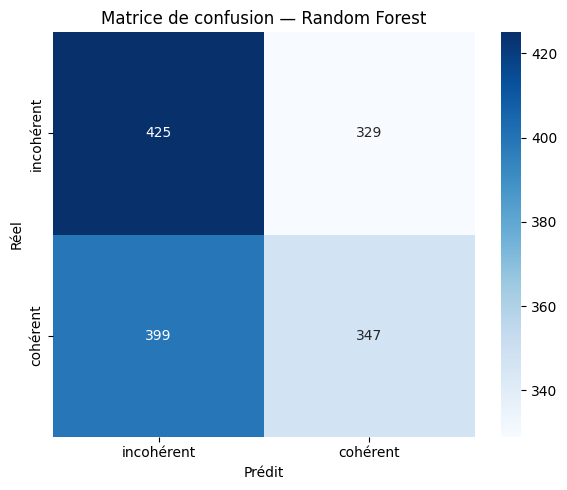

In [12]:
# Cell 10 — Évaluation finale sur le test set
best_name  = results_df['val_accuracy'].idxmax()
best_model = results[best_name]['model']

y_pred   = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print("=" * 55)
print(f"  RÉSULTAT FINAL — Pipeline 100% Classique")
print(f"  Modèle      : {best_name}")
print(f"  Test Acc    : {test_acc:.4f}")
print(f"  Test F1     : {test_f1:.4f}")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['incohérent','cohérent']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['incohérent','cohérent'],
            yticklabels=['incohérent','cohérent'])
plt.title(f'Matrice de confusion — {best_name}')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

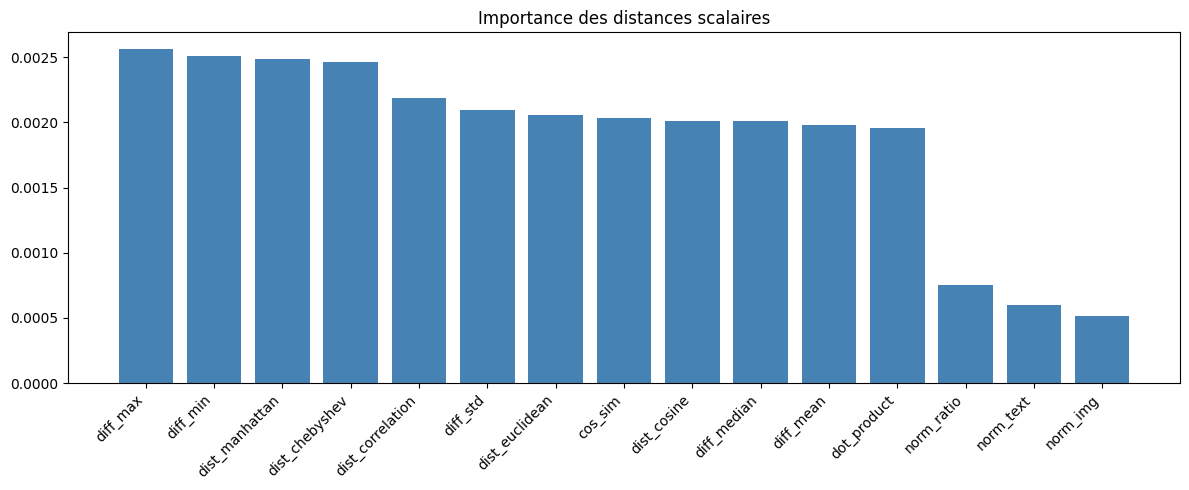


Top 5 distances les plus importantes :
  diff_max               : 0.0026
  diff_min               : 0.0025
  dist_manhattan         : 0.0025
  dist_chebyshev         : 0.0025
  dist_correlation       : 0.0022


In [13]:
# Cell 11 — Importance des features scalaires
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    imp = np.abs(best_model.coef_[0])
else:
    imp = None

if imp is not None:
    scalar_imp = imp[:len(scalar_names)]
    sorted_idx = np.argsort(scalar_imp)[::-1]

    plt.figure(figsize=(14, 5))
    plt.bar(range(len(scalar_imp)), scalar_imp[sorted_idx], color='steelblue')
    plt.xticks(range(len(scalar_imp)),
               [scalar_names[i] for i in sorted_idx],
               rotation=45, ha='right')
    plt.title('Importance des distances scalaires')
    plt.tight_layout()
    plt.show()

    print("
Top 5 distances les plus importantes :")
    for i in sorted_idx[:5]:
        print(f"  {scalar_names[i]:<22} : {scalar_imp[i]:.4f}")


In [14]:
# Cell 12 — Impact de K (dimension espace commun)
# Tester différentes valeurs de K pour trouver la meilleure

print("Test de différentes valeurs de K...")
print(f"{'K':>6} {'Val Acc':>10}")
print("-" * 20)

best_k_acc = 0
best_k     = K

for k in [32, 64, 128, 256]:
    # Re-projeter avec ce k
    p_i = PCA(n_components=k, random_state=42)
    p_t = PCA(n_components=k, random_state=42)

    vi_tr = normalize(p_i.fit_transform(F_img_train_s))
    vi_vl = normalize(p_i.transform(F_img_val_s))
    vt_tr = normalize(p_t.fit_transform(F_text_train_s))
    vt_vl = normalize(p_t.transform(F_text_val_s))

    d_tr = build_distance_dataset(vt_tr, vi_tr)
    d_vl = build_distance_dataset(vt_vl, vi_vl)

    sc   = StandardScaler()
    d_tr = sc.fit_transform(d_tr)
    d_vl = sc.transform(d_vl)

    lr  = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    lr.fit(d_tr, y_train)
    acc = accuracy_score(y_val, lr.predict(d_vl))
    print(f"{k:>6} {acc:>10.4f}" + (" ← meilleur" if acc > best_k_acc else ""))
    if acc > best_k_acc:
        best_k_acc = acc
        best_k     = k

print(f"\nMeilleure dimension K = {best_k} (Val Acc = {best_k_acc:.4f})")

Test de différentes valeurs de K...
     K    Val Acc
--------------------
    32     0.5320 ← meilleur
    64     0.5000
   128     0.5000
   256     0.4553

Meilleure dimension K = 32 (Val Acc = 0.5320)


In [ ]:
# Cell 13 — Sauvegarde
import joblib
joblib.dump(best_model,   'classical_best_model.pkl')
joblib.dump(scaler_dist,  'classical_scaler_dist.pkl')
joblib.dump(scaler_img,   'classical_scaler_img.pkl')
joblib.dump(scaler_text,  'classical_scaler_text.pkl')
joblib.dump(pca_img,      'classical_pca_img.pkl')
joblib.dump(pca_text,     'classical_pca_text.pkl')
joblib.dump(tfidf,        'classical_tfidf.pkl')

print("Fichiers sauvegardés.")
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test F1       : {test_f1:.4f}")
print("\nPipeline complet 100% classique :")
print("  Image  : HOG + HSV + LBP → PCA(K)")
print("  Texte  : TF-IDF + stats  → PCA(K)")
print("  Dataset: distances entre vecteurs image et texte")
print("  Modèle : classifieur sur ces distances")